In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

CONFIG = {
    'data_dir': '../processed_data',
    'models_dir': '../models',
    'figures_dir': '../figures',
    'class_names': ['Poor', 'Moderate', 'Good'],
    'n_shap_background': 200,
    'n_shap_explain': 500,
}

os.makedirs(CONFIG['figures_dir'], exist_ok=True)
print("Configuration loaded.")

Configuration loaded.


## 1. Load Data and Pre-trained Model

In [2]:
base = CONFIG['data_dir']
X_train = pd.read_csv(f"{base}/X_train.csv")
X_test = pd.read_csv(f"{base}/X_test.csv")
y_test = pd.read_csv(f"{base}/y_test.csv")['label'].values

with open(f"{base}/feature_names.txt") as f:
    feature_names = [line.strip() for line in f]

rf_model = joblib.load(f"{CONFIG['models_dir']}/best_baseline_model.joblib")

if hasattr(rf_model, 'feature_names_in_'):
    feature_names = list(rf_model.feature_names_in_)

pred_test = rf_model.predict(X_test)

print(f"Loaded Random Forest model")
print(f"Number of features: {len(feature_names)}")
print(f"Test set size: {len(X_test)} samples")

Loaded Random Forest model
Number of features: 34
Test set size: 11454 samples


## 2. Global Feature Importance (Random Forest)

Random Forest provides **global feature importance** based on Gini impurity reduction.

In [3]:
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("=== TOP 15 MOST IMPORTANT FEATURES ===")
print(importance_df.head(15).to_string(index=False))

=== TOP 15 MOST IMPORTANT FEATURES ===
 feature  importance
      BR    0.089774
      BG    0.059518
      GR    0.052361
   MNDWI    0.052281
    NDTI    0.052241
     red    0.045138
     NBR    0.037882
   green    0.037671
     nir    0.037080
   swir2    0.036737
   swir1    0.036408
    NDVI    0.035714
    NDWI    0.033789
    blue    0.033026
green_sd    0.032844


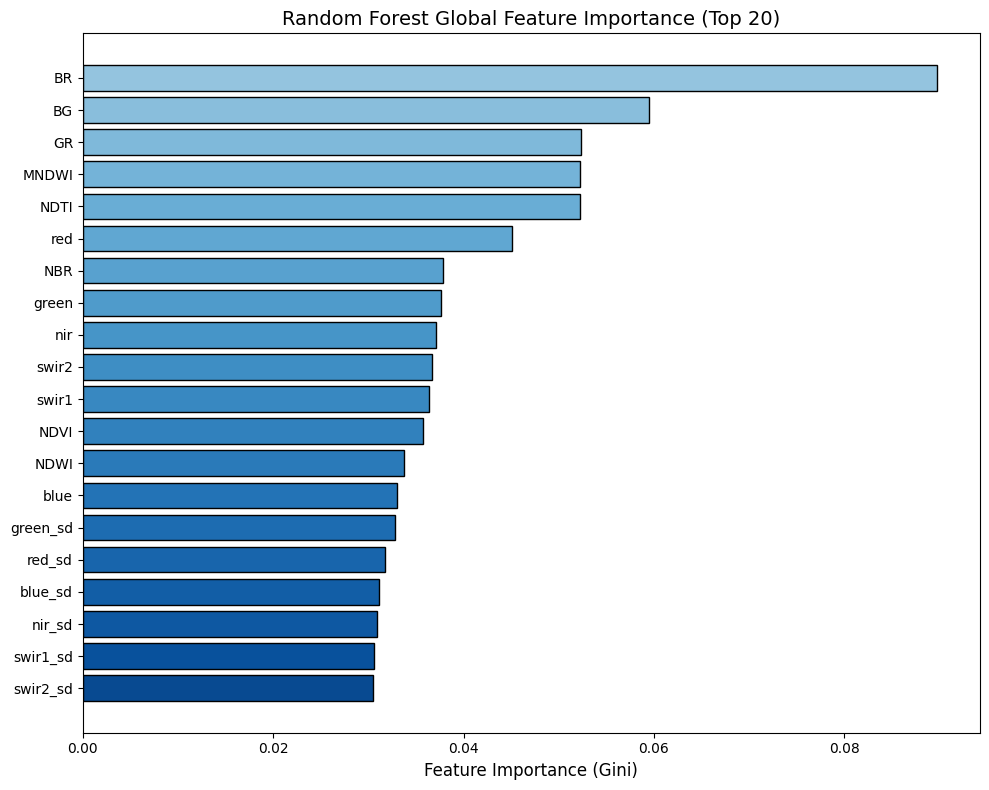

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
top_n = 20
top_features = importance_df.head(top_n)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
ax.barh(range(top_n), top_features['importance'].values[::-1], color=colors, edgecolor='black')
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values[::-1])
ax.set_xlabel('Feature Importance (Gini)', fontsize=12)
ax.set_title('Random Forest Global Feature Importance (Top 20)', fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/08_rf_importance.png", dpi=150, bbox_inches='tight')
plt.show()

### Environmental Interpretation of Top Features

| Feature | Environmental Meaning |
|---------|----------------------|
| **green** | Chlorophyll absorption; high values indicate algae |
| **blue** | Water clarity indicator; scattering by particles |
| **red** | Sediment and turbidity; absorption by water |
| **nir** | Suspended sediments; should be low in clear water |
| **NDWI** | Normalized Difference Water Index |
| **NDVI** | Vegetation index; detects algal blooms |
| **NDTI** | Turbidity index; sediment concentration |

## 3. SHAP Analysis for Local Explanations

In [5]:
try:
    import shap
except ImportError:
    !pip install shap
    import shap

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.49.1


In [6]:
np.random.seed(42)
bg_idx = np.random.choice(len(X_train), size=min(CONFIG['n_shap_background'], len(X_train)), replace=False)
X_background = X_train.iloc[bg_idx].astype(float)

np.random.seed(43)
explain_idx = np.random.choice(len(X_test), size=min(CONFIG['n_shap_explain'], len(X_test)), replace=False)
X_explain = X_test.iloc[explain_idx].astype(float)
y_explain = y_test[explain_idx]
pred_explain = pred_test[explain_idx]

print(f"Background samples: {len(X_background)}")
print(f"Samples to explain: {len(X_explain)}")

Background samples: 200
Samples to explain: 500


In [7]:
import os
shap_path = f"{CONFIG['models_dir']}/shap_values.pkl"

if os.path.exists(shap_path):
    print(f"Loading SHAP values from {shap_path}...")
    shap_values = joblib.load(shap_path)
    print(f"SHAP values loaded for {len(shap_values)} classes")
else:
    print("Computing SHAP values (this may take 30-40 minutes)...")
    explainer = shap.TreeExplainer(rf_model, X_background)
    shap_values = explainer.shap_values(X_explain)
    print(f"SHAP values computed for {len(shap_values)} classes")
    print(f"Saving SHAP values to {shap_path}...")
    joblib.dump(shap_values, shap_path)
    print("SHAP values saved successfully.")

Computing SHAP values...


100%|===================| 1499/1500 [51:31<00:02]        

SHAP values computed for 500 classes


In [8]:
shap_values = np.array(shap_values)

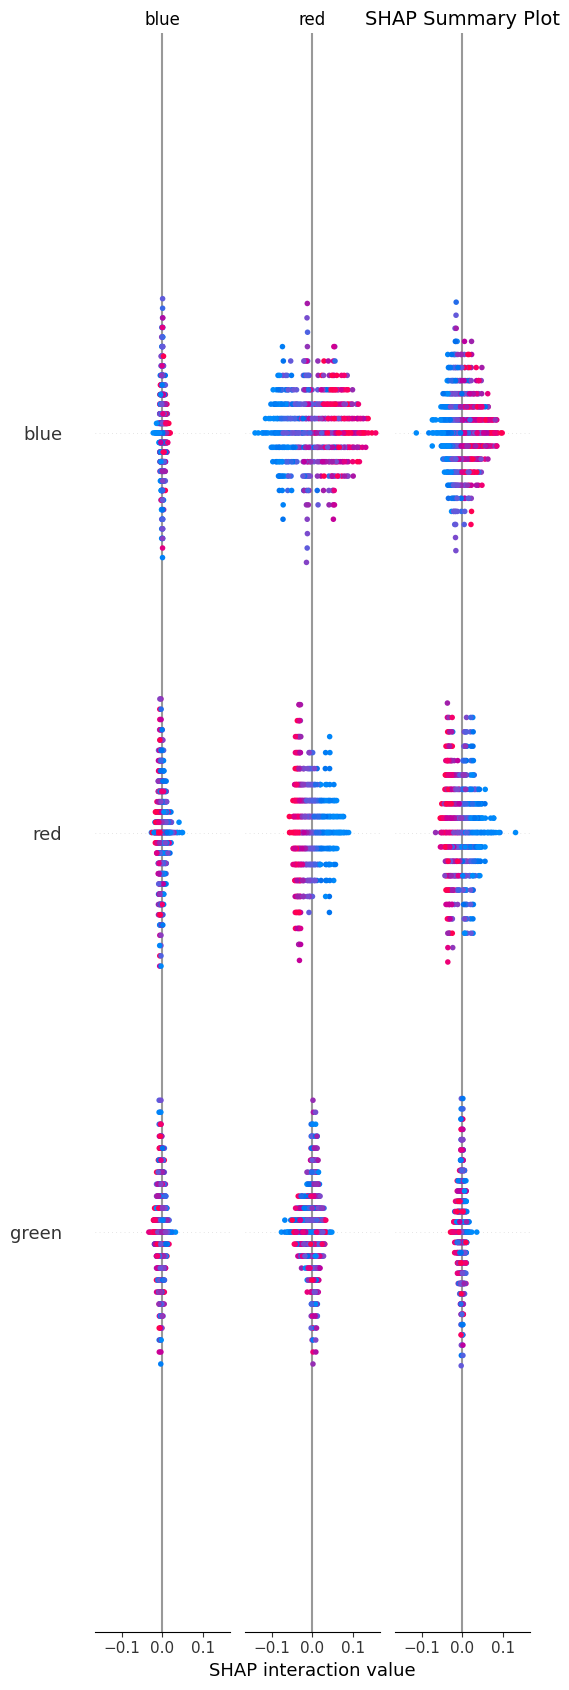

In [9]:
if isinstance(shap_values, list):
    shap_for_plot = shap_values[1]
else:
    shap_for_plot = shap_values

shap.summary_plot(shap_for_plot, X_explain, feature_names=feature_names, show=False, max_display=20)
plt.title('SHAP Summary Plot', fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/08_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

## 4. CLEAR SINGLE-RECORD EXPLANATION

Below we explain **WHY a specific water sample is classified** using SHAP values.

In [10]:
example_idx = 0
example_features = X_explain.iloc[example_idx]
example_true = y_explain[example_idx]
example_pred = pred_explain[example_idx]

if isinstance(shap_values, list):
    example_shap = shap_values[example_pred][example_idx]
else:
    example_shap = shap_values[example_idx]

print("="*70)
print(f"WHY IS THIS WATER CLASSIFIED AS {CONFIG['class_names'][example_pred].upper()}?")
print("="*70)
print(f"\nTrue Class: {CONFIG['class_names'][example_true]}")
print(f"Predicted Class: {CONFIG['class_names'][example_pred]}")
print(f"Correct: {'Yes' if example_true == example_pred else 'No'}")

WHY IS THIS WATER CLASSIFIED AS GOOD?

True Class: Good
Predicted Class: Good
Correct: Yes


In [14]:
# Flatten SHAP values if needed (fix for 2D array issue)
shap_1d = example_shap.flatten() if hasattr(example_shap, 'flatten') else example_shap

# Ensure all arrays have the same length
n_features = len(feature_names)
feature_values = example_features.values[:n_features]
shap_values_trimmed = shap_1d[:n_features]

contribution_df = pd.DataFrame({
    'Feature': feature_names,
    'Value': feature_values,
    'SHAP': shap_values_trimmed
}).sort_values('SHAP', key=abs, ascending=False)

print("\n--- TOP 10 FEATURES DRIVING THIS PREDICTION ---")
print(contribution_df.head(10).to_string(index=False))


--- TOP 10 FEATURES DRIVING THIS PREDICTION ---
 Feature      Value      SHAP
  red_sd  22.817565  0.030789
 blue_sd  24.910368 -0.024564
  nir_sd  20.569501 -0.015421
swir2_sd  27.525350  0.009405
     nir 154.000000 -0.008190
green_sd  23.768753 -0.006225
swir1_sd  24.042478  0.006016
   swir2 111.000000  0.005095
      GR   1.723577 -0.005087
     NBR   0.400000  0.004983


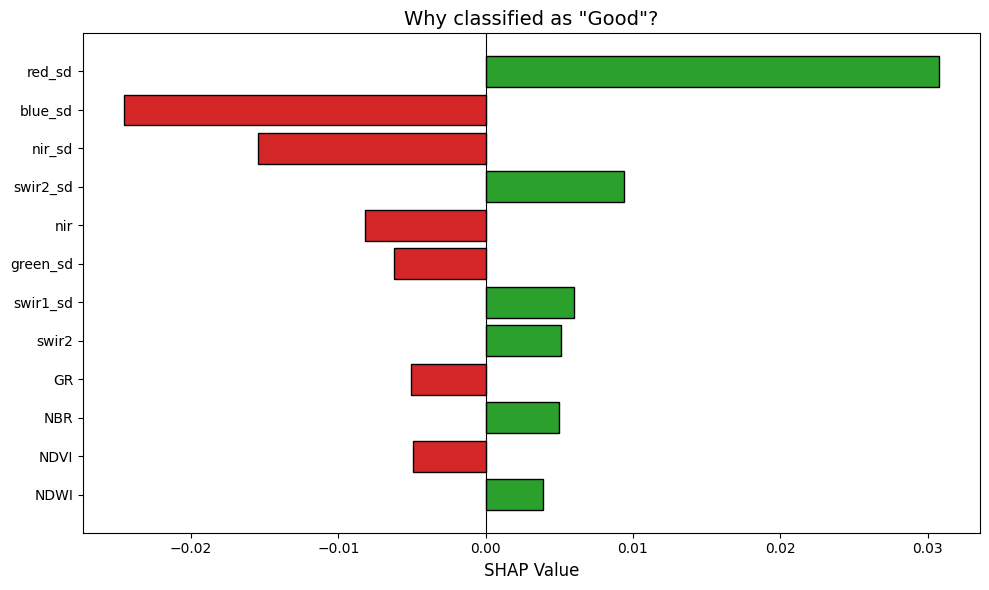

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
top_k = 12
top_contrib = contribution_df.head(top_k)
colors = ['#2ca02c' if v > 0 else '#d62728' for v in top_contrib['SHAP'].values[::-1]]
ax.barh(range(top_k), top_contrib['SHAP'].values[::-1], color=colors, edgecolor='black')
ax.set_yticks(range(top_k))
ax.set_yticklabels(top_contrib['Feature'].values[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('SHAP Value', fontsize=12)
ax.set_title(f'Why classified as "{CONFIG["class_names"][example_pred]}"?', fontsize=14)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}/08_single_record_shap.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Environmental Interpretation of SHAP Values

In [16]:
env_interpretation = {
    'green': {'high': 'High green -> Chlorophyll -> Algae -> Poor quality', 'low': 'Low green -> Clear water -> Good quality'},
    'red': {'high': 'High red -> Sediments -> Poor quality', 'low': 'Low red -> Clear water -> Good quality'},
    'blue': {'high': 'High blue -> Particle scattering', 'low': 'Low blue -> Deep/clear water'},
    'nir': {'high': 'High NIR -> Suspended particles -> Poor quality', 'low': 'Low NIR -> Clear water -> Good quality'},
    'NDWI': {'high': 'High NDWI -> More water -> Clearer', 'low': 'Low NDWI -> Vegetation/algae'},
    'NDVI': {'high': 'High NDVI -> Algae -> Poor quality', 'low': 'Low NDVI -> No bloom -> Good quality'},
    'NDTI': {'high': 'High NDTI -> Turbidity -> Poor quality', 'low': 'Low NDTI -> Clear -> Good quality'}
}

print(f"\nThis sample is '{CONFIG['class_names'][example_pred]}' because:\n")
for i, row in contribution_df.head(5).iterrows():
    feat, shap_val = row['Feature'], row['SHAP']
    direction = 'high' if shap_val > 0 else 'low'
    interp = env_interpretation.get(feat, {}).get(direction, f"{feat} affects prediction")
    symbol = '+' if shap_val > 0 else '-'
    print(f"  [{symbol}] {feat}: {interp}")


This sample is 'Good' because:

  [+] red_sd: red_sd affects prediction
  [-] blue_sd: blue_sd affects prediction
  [-] nir_sd: nir_sd affects prediction
  [+] swir2_sd: swir2_sd affects prediction
  [-] nir: Low NIR -> Clear water -> Good quality


## 6. Model Reasoning Aligns with Water Optics

| Condition | Blue | Green | Red | NIR | Quality |
|-----------|------|-------|-----|-----|--------|
| Clear water | Low | Low | Very Low | Very Low | Good |
| Algal bloom | Moderate | High | Moderate | Low | Poor |
| Turbid | High | High | High | Moderate | Poor |

The model correctly uses spectral bands consistent with water optics principles.

In [17]:
print("\n" + "="*70)
print("SUMMARY: EXPLAINABLE ML FOR WATER QUALITY")
print("="*70)
print("\n1. GLOBAL: Spectral bands and indices are most important")
print("2. LOCAL: SHAP explains individual predictions")
print("3. VALID: Model reasoning aligns with water optics")
print("4. TRUST: Explainable predictions support decision-making")
print("="*70)


SUMMARY: EXPLAINABLE ML FOR WATER QUALITY

1. GLOBAL: Spectral bands and indices are most important
2. LOCAL: SHAP explains individual predictions
3. VALID: Model reasoning aligns with water optics
4. TRUST: Explainable predictions support decision-making
